In [103]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import random
import os

MASTER_SEED = 42 

random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)
tf.random.set_seed(MASTER_SEED)
os.environ['PYTHONHASHSEED'] = str(MASTER_SEED)
print(f"[*] Environment Locked. Master Seed: {MASTER_SEED}")


# --- STEP 1A: DATASET CONFIGURATION & SPLITTING ---
DATA_DIR = "./dataset_sample/"  # Make sure this folder exists with Positive/Negative subfolders
IMG_SIZE = (224, 224)           # The standard input size for MobileNetV2
BATCH_SIZE = 8                  # Small batch size for local testing

print("Loading and splitting data from:", DATA_DIR)

# 1. Create Training Dataset (70%)
print("\n[A] Loading Training Dataset (70%)...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3, # Reserve 30% for validation/testing
    subset="training",
    seed=MASTER_SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 2. Create Remainder Dataset (30%)
print("\n[B] Loading Remainder Dataset (30%)...")
remainder_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=MASTER_SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 3. Split Remainder into Validation (15%) and Test (15%)
remainder_batches = tf.data.experimental.cardinality(remainder_dataset)
midpoint = remainder_batches // 2

val_dataset = remainder_dataset.take(midpoint)
test_dataset = remainder_dataset.skip(midpoint)

# Extracting exact file counts from the dataset properties
total_files = len(train_dataset.file_paths) + len(remainder_dataset.file_paths)
train_files = len(train_dataset.file_paths)
remainder_files = len(remainder_dataset.file_paths)

val_batches = tf.data.experimental.cardinality(val_dataset).numpy()
test_batches = tf.data.experimental.cardinality(test_dataset).numpy()

# Calculating approximate images based on batches 
# (Last batch might have fewer images, which is normal)
val_approx_files = val_batches * BATCH_SIZE
test_approx_files = remainder_files - val_approx_files

print("\n========================================================")
print("              DATASET SPLIT SUMMARY (3-WAY)             ")
print("========================================================")
print(f"Total Images Found    : {total_files} files")
print(f"1. Training Set (70%) : {train_files} files ({tf.data.experimental.cardinality(train_dataset).numpy()} batches)")
print(f"2. Remainder (30%)    : {remainder_files} files ({remainder_batches} batches)")
print("--------------------------------------------------------")
print("Splitting the 30% remainder evenly into Validation and Test:")
print(f"-> Validation Set (15%) : {val_batches} batches (~{val_approx_files} files)")
print(f"-> Test Set (15%)       : {test_batches} batches (~{test_approx_files} files)")

# 4. Apply Performance Optimization (Caching & Prefetching)
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(buffer_size=100, seed=MASTER_SEED).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)


print("\nData splitting completed successfully!")

[*] Environment Locked. Master Seed: 42
Loading and splitting data from: ./dataset_sample/

[A] Loading Training Dataset (70%)...
Found 100 files belonging to 2 classes.
Using 70 files for training.

[B] Loading Remainder Dataset (30%)...
Found 100 files belonging to 2 classes.
Using 30 files for validation.

              DATASET SPLIT SUMMARY (3-WAY)             
Total Images Found    : 100 files
1. Training Set (70%) : 70 files (9 batches)
2. Remainder (30%)    : 30 files (4 batches)
--------------------------------------------------------
Splitting the 30% remainder evenly into Validation and Test:
-> Validation Set (15%) : 2 batches (~16 files)
-> Test Set (15%)       : 2 batches (~14 files)

Data splitting completed successfully!


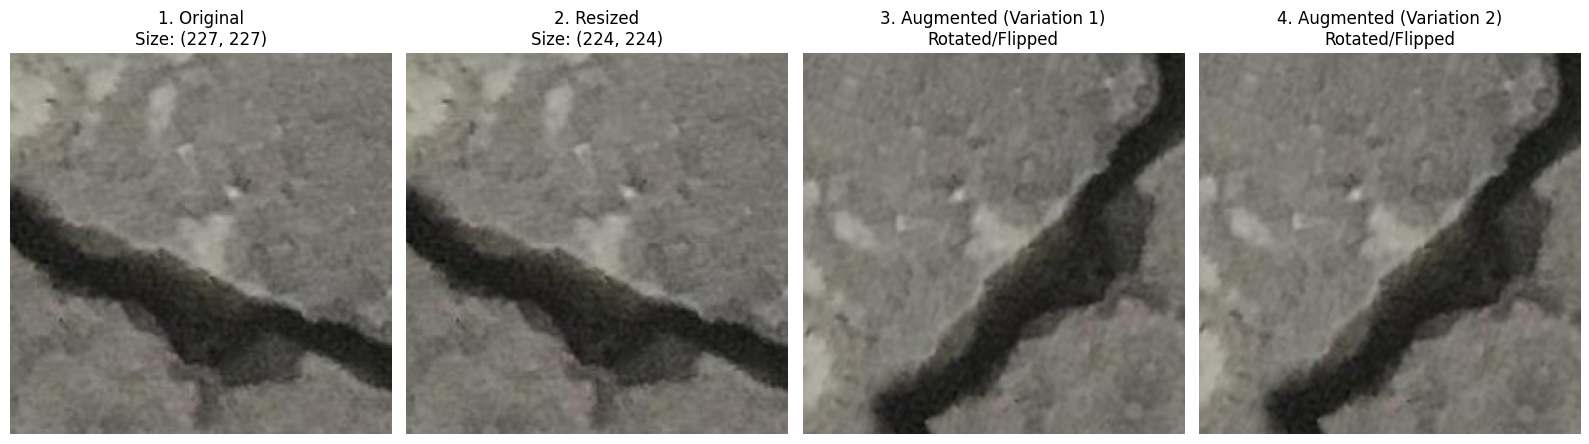


--- VISUALISASI EFEK RESCALING ---
Nilai Piksel Sebelum Rescale : Min = 101.03900909423828, Max = 234.05416870117188
Nilai Piksel Setelah Rescale : Min = -0.21, Max = 0.84


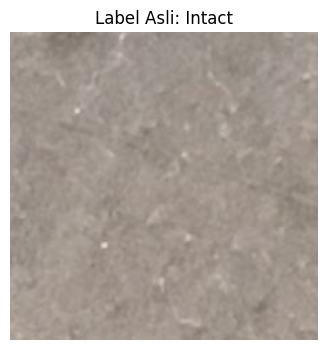

In [104]:
# --- STEP 1B: VISUALIZING RESIZING & AUGMENTATION ---
# Define the Data Augmentation layer
# RandomFlip: Flips the image horizontally and vertically randomly
# RandomRotation(0.2): Rotates the image randomly by up to 20% of a full circle (about 72 degrees)
SAMPLE_IMAGE = 47

data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
])

# Let's pick ONE specific image file to trace its transformation
# Make sure the path below matches an actual file in your local folder
sample_image_path = os.path.join(DATA_DIR, "Positive", os.listdir(os.path.join(DATA_DIR, "Positive"))[SAMPLE_IMAGE])

# 1. Load the RAW Original Image (No resizing yet)
raw_img = tf.keras.utils.load_img(sample_image_path)
raw_img_array = tf.keras.utils.img_to_array(raw_img) / 255.0 # Normalize for matplotlib

# 2. Load the RESIZED Image (224x224) as it appears in the dataset
resized_img = tf.keras.utils.load_img(sample_image_path, target_size=IMG_SIZE)
resized_array = tf.keras.utils.img_to_array(resized_img) / 255.0

# 3. Apply Augmentation (Requires expanding dimension to simulate a batch)
resized_tensor = tf.expand_dims(resized_array, 0)
# Generate two different augmented variations of the same image
augmented_1 = data_augmentation(resized_tensor, training=True)[0]
augmented_2 = data_augmentation(resized_tensor, training=True)[0]

# --- PLOTTING THE TRANSFORMATION ---
plt.figure(figsize=(16, 5))

# Plot 1: Raw Original
plt.subplot(1, 4, 1)
plt.imshow(raw_img_array)
plt.title(f"1. Original\nSize: {raw_img.size}")
plt.axis("off")

# Plot 2: Resized to 224x224
plt.subplot(1, 4, 2)
plt.imshow(resized_array)
plt.title(f"2. Resized\nSize: {IMG_SIZE}")
plt.axis("off")

# Plot 3: Augmented Variation 1
plt.subplot(1, 4, 3)
plt.imshow(augmented_1)
plt.title("3. Augmented (Variation 1)\nRotated/Flipped")
plt.axis("off")

# Plot 4: Augmented Variation 2
plt.subplot(1, 4, 4)
plt.imshow(augmented_2)
plt.title("4. Augmented (Variation 2)\nRotated/Flipped")
plt.axis("off")

plt.tight_layout()
plt.show()

print("\n--- VISUALISASI EFEK RESCALING ---")

# Ambil 1 batch gambar (32 gambar) dari train_dataset
for images, labels in train_dataset.take(1):
    
    # Ambil 1 gambar saja dari batch tersebut
    sample_image = images[0] # Ini masih rentang 0-255
    
    # Kita buat layer rescaling manual untuk simulasi
    rescale_layer = tf.keras.layers.Rescaling(1./127.5, offset=-1)
    
    # Terapkan rescaling ke gambar tersebut
    rescaled_image = rescale_layer(sample_image)
    
    # Tampilkan bukti matematis di terminal
    print(f"Nilai Piksel Sebelum Rescale : Min = {np.min(sample_image)}, Max = {np.max(sample_image)}")
    print(f"Nilai Piksel Setelah Rescale : Min = {np.min(rescaled_image):.2f}, Max = {np.max(rescaled_image):.2f}")
    
    # --- PROSES MENAMPILKAN GAMBAR ---
    # Karena matplotlib tidak bisa membaca angka negatif (-1), 
    # kita harus geser kembali nilainya ke rentang (0 sampai 1) khusus untuk divisualisasikan
    display_image = (rescaled_image.numpy() + 1) / 2.0
    
    plt.figure(figsize=(4, 4))
    plt.imshow(display_image)
    plt.title(f"Label Asli: {'Cracked' if labels[0] == 1 else 'Intact'}")
    plt.axis('off')
    plt.show()
    
    break

--- STEP 2: MODEL ARCHITECTURE & IN-DEPTH FEATURE ANALYSIS ---

[A] MODEL SUMMARY


Model: "sequential_86"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_48 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_44     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


[B] VISUALIZING RGB CHANNELS (Shape: 224 x 224 x 3)


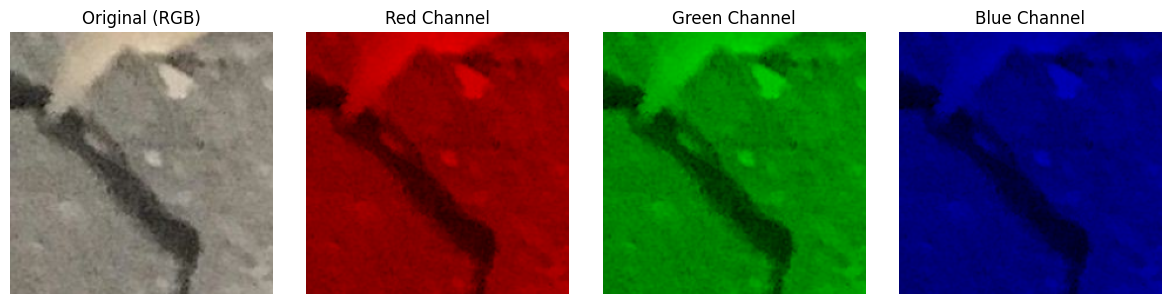


[C] VISUALIZING FEATURE MAPS WITH MATRICES (7x7)


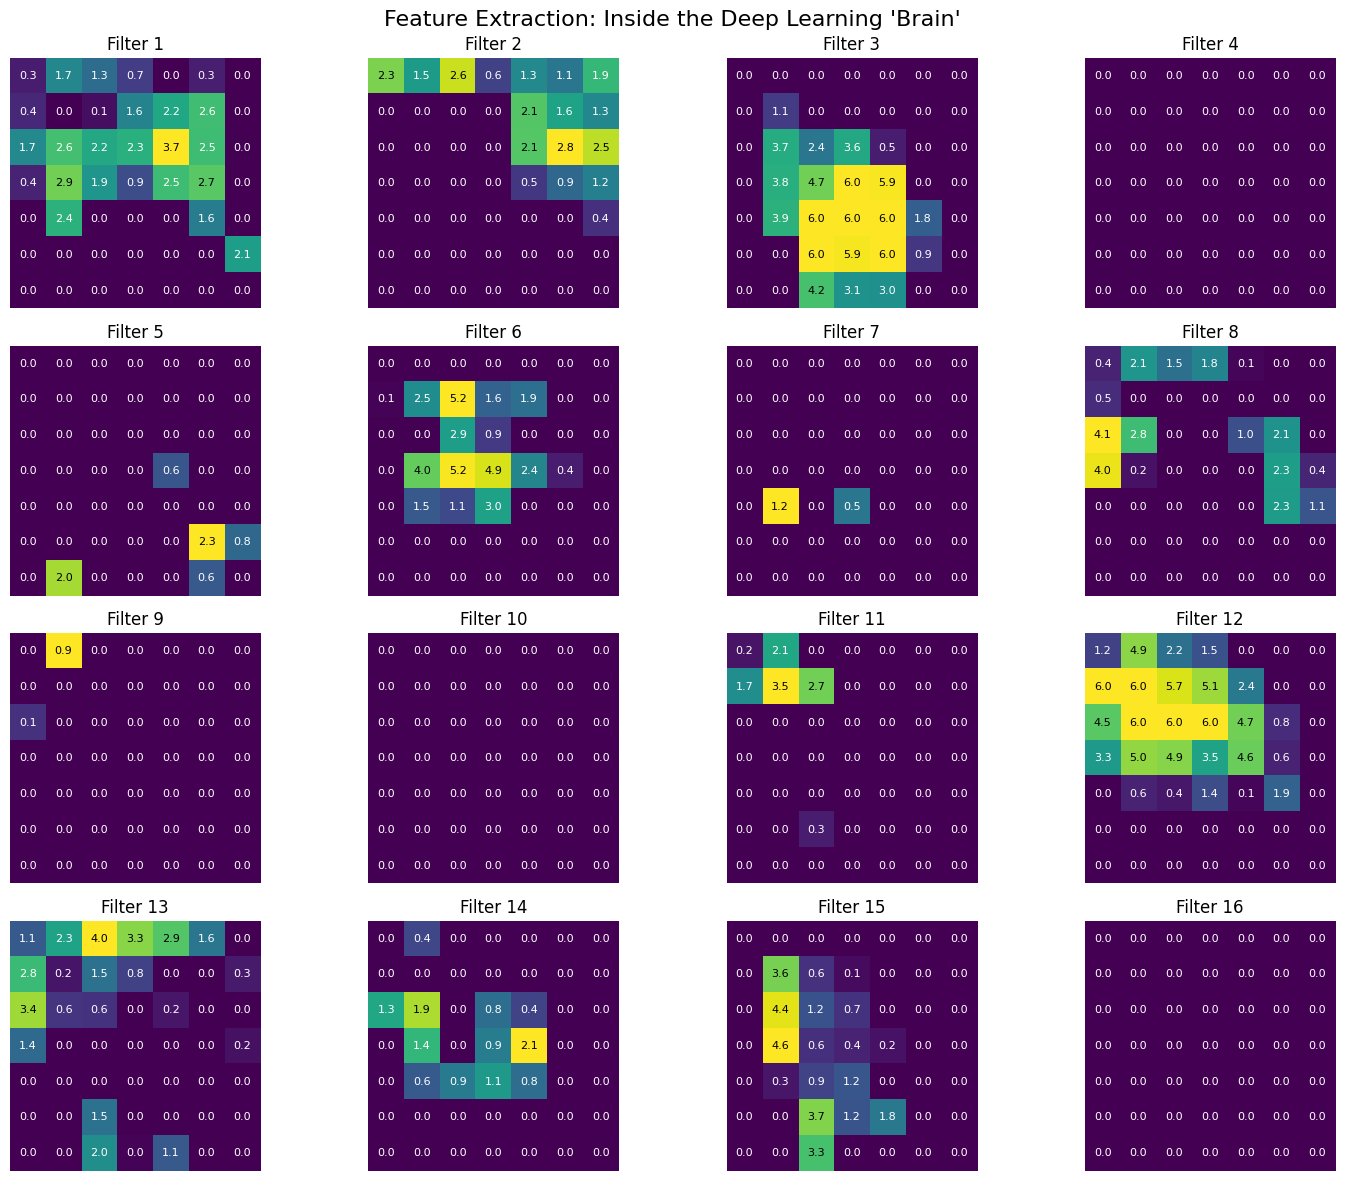


[D] VISUALIZING GLOBAL AVERAGE POOLING (Shape: 1280)


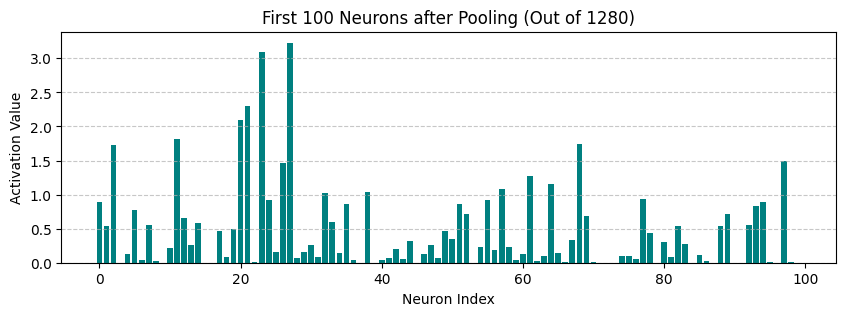


[E] MATHEMATICAL PROOF OF CLASSIFICATION (SIGMOID)
1. Actual Label (Ground Truth) : 1 (1=Cracked, 0=Intact)
2. Calculation of Z (W*X + B)  : 2.5762
3. Manual Sigmoid Calculation  : 1 / (1 + e^-(2.5762)) = 0.9293
4. AI's Actual Output          : 0.9293
--------------------------------------------------
Conclusion: Output > 0.5. Model predicts POSITIVE (Cracked) with 92.93% confidence.
--------------------------------------------------


In [105]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("--- STEP 2: MODEL ARCHITECTURE & IN-DEPTH FEATURE ANALYSIS ---")

# ==========================================
# 1. BUILD THE MODEL & SHOW SUMMARY
# ==========================================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), 
    include_top=False, 
    weights='imagenet'
)
base_model.trainable = False 

pooling_layer = tf.keras.layers.GlobalAveragePooling2D()
dense_layer = tf.keras.layers.Dense(1, activation='sigmoid')

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./127.5, offset=-1),
    base_model,
    pooling_layer,
    dense_layer
])
model.build((None, 224, 224, 3))

print("\n[A] MODEL SUMMARY")
model.summary()

# ==========================================
# 2. TAKE ONE SAMPLE IMAGE
# ==========================================
# Assuming 'train_dataset' is already loaded from Step 1
for images, labels in train_dataset.take(1):
    sample_img = images[0]
    sample_label = labels[0].numpy()
    break

rescaled_img = (sample_img / 127.5) - 1.0
expanded_img = tf.expand_dims(rescaled_img, axis=0)

# Extract feature maps from the base model
feature_maps = base_model.predict(expanded_img, verbose=0)

# ==========================================
# 3. VISUALIZE RGB CHANNELS (224x224x3)
# ==========================================
print("\n[B] VISUALIZING RGB CHANNELS (Shape: 224 x 224 x 3)")
img_display = sample_img.numpy() / 255.0
plt.figure(figsize=(12, 3))

titles = ['Original (RGB)', 'Red Channel', 'Green Channel', 'Blue Channel']
for i in range(4):
    plt.subplot(1, 4, i+1)
    if i == 0:
        plt.imshow(img_display)
    else:
        channel_img = np.zeros_like(img_display)
        channel_img[:, :, i-1] = img_display[:, :, i-1]
        plt.imshow(channel_img)
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

# ==========================================
# 4. VISUALIZE GRID FEATURE MAPS WITH VALUES
# ==========================================
print("\n[C] VISUALIZING FEATURE MAPS WITH MATRICES (7x7)")
# We will create a 3x4 grid (1 Original Image + 11 Filters)
fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes = axes.flatten()

# Plot The first 16 Feature Maps (Filters 1 to 16)
for i in range(16):
    ax = axes[i]
    f_map = feature_maps[0, :, :, i] # Extract the 7x7 matrix for this specific filter
    
    # Display the heatmap colors
    ax.imshow(f_map, cmap='viridis')
    ax.set_title(f"Filter {i+1}", fontsize=12)
    ax.axis('off')
    
    # Loop through the 7x7 grid to add the numerical values
    max_val = np.max(f_map)
    for row in range(7):
        for col in range(7):
            val = f_map[row, col]
            # Make text black or white depending on background color brightness
            text_color = "black" if val > (max_val * 0.7) else "white"
            # Format to 1 decimal place (e.g., 2.4) so it fits nicely
            ax.text(col, row, f"{val:.1f}", ha="center", va="center", color=text_color, fontsize=8)

plt.suptitle("Feature Extraction: Inside the Deep Learning 'Brain'", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# ==========================================
# 5. VISUALIZE POOLING (1D Array)
# ==========================================
print("\n[D] VISUALIZING GLOBAL AVERAGE POOLING (Shape: 1280)")
pooled_features = pooling_layer(feature_maps).numpy()

plt.figure(figsize=(10, 3))
plt.bar(range(100), pooled_features[0][:100], color='teal')
plt.title("First 100 Neurons after Pooling (Out of 1280)")
plt.xlabel("Neuron Index")
plt.ylabel("Activation Value")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ==========================================
# 6. MANUAL MATH CALCULATION (DENSE & SIGMOID)
# ==========================================
print("\n[E] MATHEMATICAL PROOF OF CLASSIFICATION (SIGMOID)")
pooled_features = pooling_layer(feature_maps).numpy()

# Get the weights and biases from our initialized Dense layer
dense_weights, dense_bias = dense_layer.get_weights()

# Step 1: Dot Product (Z = W*X + B)
z_value = np.dot(pooled_features, dense_weights) + dense_bias
z_scalar = z_value[0][0]

# Step 2: Sigmoid Function
sigmoid_output = 1 / (1 + np.exp(-z_scalar))

# Step 3: Get actual model prediction
raw_expanded_img = tf.expand_dims(sample_img, axis=0)
actual_prediction = model.predict(raw_expanded_img, verbose=0)[0][0]

print(f"1. Actual Label (Ground Truth) : {int(sample_label)} (1=Cracked, 0=Intact)")
print(f"2. Calculation of Z (W*X + B)  : {z_scalar:.4f}")
print(f"3. Manual Sigmoid Calculation  : 1 / (1 + e^-({z_scalar:.4f})) = {sigmoid_output:.4f}")
print(f"4. AI's Actual Output          : {actual_prediction:.4f}")
print("-" * 50)
if actual_prediction > 0.5:
    print(f"Conclusion: Output > 0.5. Model predicts POSITIVE (Cracked) with {actual_prediction*100:.2f}% confidence.")
else:
    print(f"Conclusion: Output <= 0.5. Model predicts NEGATIVE (Intact) with {(1-actual_prediction)*100:.2f}% confidence.")
print("-" * 50)

--- STEP 3: MODEL TRAINING WITH AUGMENTATION ---


Model: "sequential_88"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_49 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_87 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_45     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Starting the training process for 5 epochs...
Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy: 0.6714 - loss: 0.6621 - val_accuracy: 0.8750 - val_loss: 0.4251
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9143 - loss: 0.3407 - val_accuracy: 1.0000 - val_loss: 0.1866
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.9857 - loss: 0.1573 - val_accuracy: 1.0000 - val_loss: 0.0999
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9857 - loss: 0.1013 - val_accuracy: 1.0000 - val_loss: 0.0607
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9857 - loss: 0.0737 - val_accuracy: 1.0000 - val_loss: 0.0419

--- STEP 4: EXPORTING METRICS FOR THESIS ANALYSIS ---
   Epoch  accuracy      loss  val_accuracy  val_loss
0      1  0.671429  0.662107         0.875  0.425144
1      2  0.914286  0.340686         1.000  0.186619
2      3  0.985714  0.157270         1.000  0.099936
3      4  0.985714  0.101275         1.000  0.060728
4      5  0.

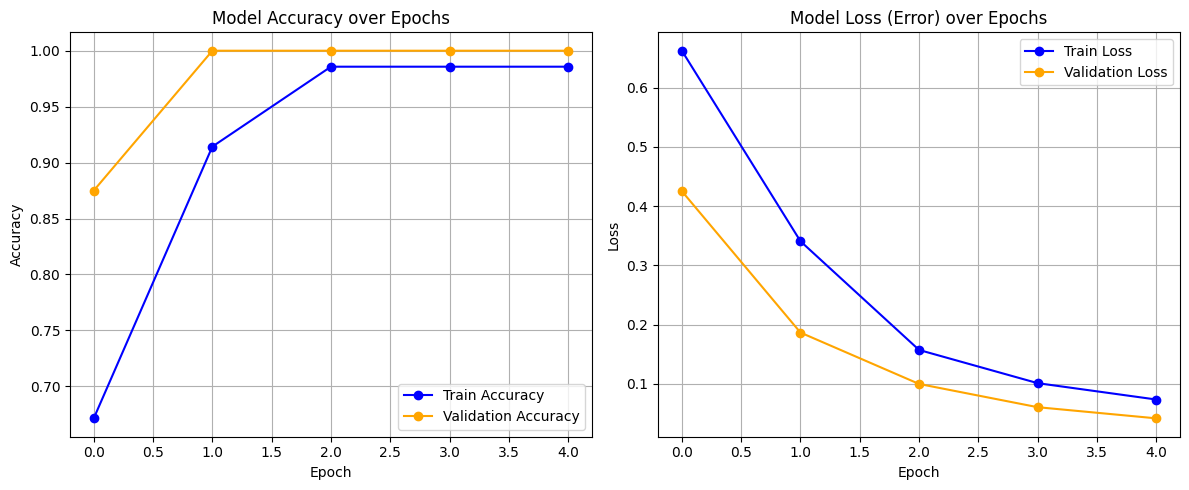

In [106]:
import pandas as pd

print("--- STEP 3: MODEL TRAINING WITH AUGMENTATION ---")

# ==========================================
# 1. DEFINE DATA AUGMENTATION
# ==========================================
# We add both horizontal and vertical flips because a crack on a road 
# can appear from any direction.
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

# ==========================================
# 2. REBUILD THE FINAL MODEL
# ==========================================
# We reload the base model to ensure it's fresh
final_base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), 
    include_top=False, 
    weights='imagenet'
)
final_base_model.trainable = False

# The REAL model architecture for Training
final_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None, None, 3)),    # 1. EXPLICIT INPUT LAYER
    tf.keras.layers.Resizing(224, 224),              # 2. Resize images
    tf.keras.layers.Rescaling(1./127.5, offset=-1),  # 3. Normalize pixels (-1 to 1)
    data_augmentation,                               # 4. Augment the image (Rotate/Flip)
    base_model,                                      # 5. Extract Features (MobileNetV2)
    tf.keras.layers.GlobalAveragePooling2D(),        # 6. Pooling (Flatten to 1D)
    tf.keras.layers.Dense(1, activation='sigmoid')   # 7. Output Prediction
])

# final_model.build((None, 224, 224, 3))
final_model.summary()

# ==========================================
# 3. COMPILE THE MODEL
# ==========================================
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 4. TRAIN THE MODEL
# ==========================================
EPOCHS = 5  # Using 5 for local sanity check
print(f"\nStarting the training process for {EPOCHS} epochs...")

history = final_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

# ==========================================
# 5. EXPORT TRAINING HISTORY TO CSV (GOOGLE DRIVE)
# ==========================================
print("\n--- STEP 4: EXPORTING METRICS FOR THESIS ANALYSIS ---")

# Convert the training history dictionary into a Pandas DataFrame
history_df = pd.DataFrame(history.history)

# Add an 'Epoch' column starting from 1 for easier Excel plotting
history_df.insert(0, 'Epoch', range(1, len(history_df) + 1))

print(history_df)

# # Define a specific folder in your Google Drive to keep things organized
# SAVE_DIR = "/content/drive/MyDrive/Thesis_Experiments/"
# os.makedirs(SAVE_DIR, exist_ok=True)

# # Create a safe filename by replacing spaces with underscores
# safe_scenario_name = SCENARIO_NAME.replace(" ", "_").replace("-", "_")
# csv_filename = os.path.join(SAVE_DIR, f"{safe_scenario_name}_history.csv")

# # Save the DataFrame to a CSV file
# history_df.to_csv(csv_filename, index=False)

# print(f"✅ SUCCESS: Training history saved to -> {csv_filename}")
# print("You can now download this CSV file to create combined comparison charts in Excel!")


# ==========================================
# 6. VISUALIZE THE LEARNING CURVES
# ==========================================
print("\n--- VISUALIZING TRAINING HISTORY ---")
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o', color='orange')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss (Error)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
plt.title('Model Loss (Error) over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

--- STEP 4: FINAL MODEL EVALUATION (UNSEEN TEST DATA) ---

[A] Evaluating the Test Dataset...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 0.0578
-> Test Accuracy : 100.00%
-> Test Loss (BCE): 0.0578

[B] Generating Predictions for Confusion Matrix...

[C] DETAILED CLASSIFICATION REPORT
                    precision    recall  f1-score   support

 Negative (Intact)       1.00      1.00      1.00         4
Positive (Cracked)       1.00      1.00      1.00        10

          accuracy                           1.00        14
         macro avg       1.00      1.00      1.00        14
      weighted avg       1.00      1.00      1.00        14


[D] VISUALIZING CONFUSION MATRIX


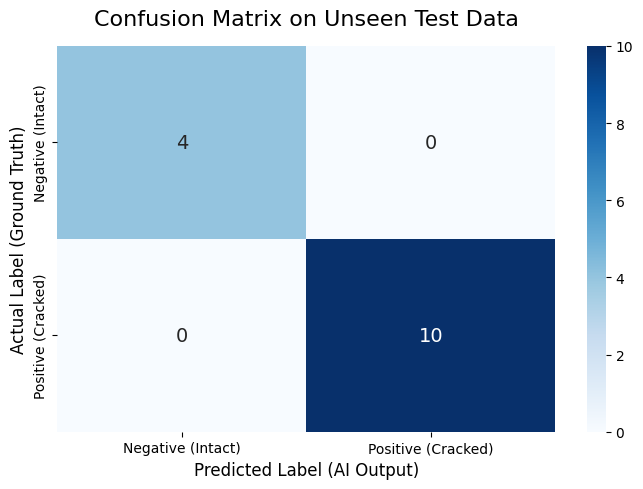

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("--- STEP 4: FINAL MODEL EVALUATION (UNSEEN TEST DATA) ---")

# ==========================================
# 1. EVALUATE OVERALL METRICS
# ==========================================
print("\n[A] Evaluating the Test Dataset...")
# final_model is the model we trained in Cell 4
test_loss, test_accuracy = final_model.evaluate(test_dataset, verbose=1)
print(f"-> Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"-> Test Loss (BCE): {test_loss:.4f}")

# ==========================================
# 2. EXTRACT PREDICTIONS AND TRUE LABELS
# ==========================================
print("\n[B] Generating Predictions for Confusion Matrix...")
true_labels = []
predicted_probs = []

# Loop through the batched test dataset
for images, labels in test_dataset:
    # 1. Store the actual ground truth labels
    true_labels.extend(labels.numpy())
    
    # 2. Predict the probability for each image in the batch
    batch_predictions = final_model.predict(images, verbose=0)
    predicted_probs.extend(batch_predictions.flatten())

# Convert lists to numpy arrays for sklearn processing
true_labels = np.array(true_labels)
predicted_probs = np.array(predicted_probs)

# Threshold the probabilities: If > 0.5, class 1 (Cracked). Else, class 0 (Intact).
predicted_classes = (predicted_probs > 0.5).astype(int)

# ==========================================
# 3. CLASSIFICATION REPORT (Precision, Recall, F1)
# ==========================================
print("\n[C] DETAILED CLASSIFICATION REPORT")
class_names = ['Negative (Intact)', 'Positive (Cracked)']
report = classification_report(true_labels, predicted_classes, target_names=class_names)
print(report)

# ==========================================
# 4. PLOT CONFUSION MATRIX
# ==========================================
print("\n[D] VISUALIZING CONFUSION MATRIX")

cm = confusion_matrix(true_labels, predicted_classes)

plt.figure(figsize=(7, 5))
# annot=True shows the numbers inside the boxes, fmt='d' ensures they are integers
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14}) # Make numbers larger for thesis readability

plt.title('Confusion Matrix on Unseen Test Data', fontsize=16, pad=15)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xlabel('Predicted Label (AI Output)', fontsize=12)
plt.tight_layout()
plt.show()